## RFM Analysis
RFM segments customers based on their purchasing behavior:

- Recency: How recently a customer made a purchase  
- Frequency: How often a customer makes purchases  
- Monetary: How much a customer spends  

This helps identify valuable customers and supports targeted marketing and retention strategies.


## Data Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("~/Customer-Segmentation-and-Churn-Analysis/data/cleaned_data.csv")

In [3]:
# Convert InvoiceDate to datetime and calculate TotalPrice
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Use the latest invoice date as reference for Recency calculation
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

## RFM Table Creation

In [4]:
# Calculate Recency, Frequency, and Monetary values for each customer
rfm = df.groupby('CustomerID').agg({
    "InvoiceDate" : lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo" : "nunique",
    "TotalPrice" : "sum"
}).reset_index()

# Rename columns for clarity
rfm.columns = ['CustomerID','Recency','Frequency','Monetary']
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


## Exploratory Analysis of RFM
Visualize the distributions of Recency, Frequency, and Monetary values (Note: Frequency and Monetary are skewed, so some bars may appear thin).

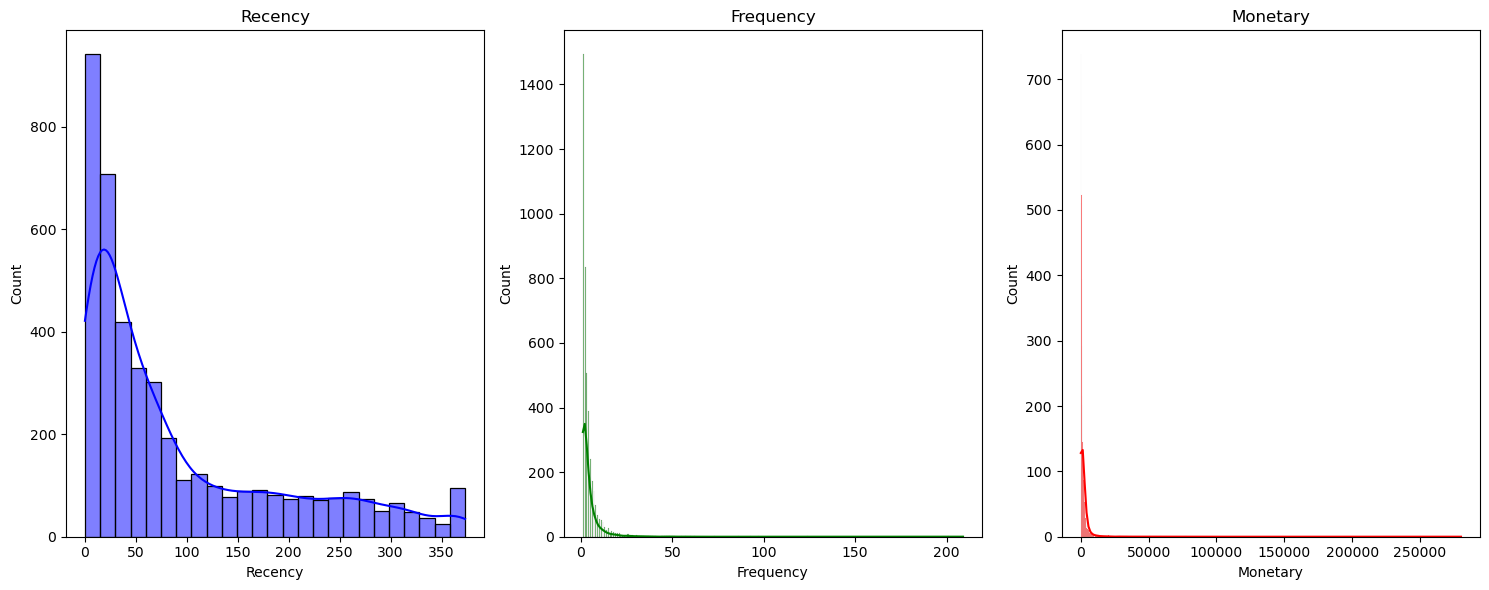

In [5]:
# Plot distributions of Recency, Frequency, and Monetary values
fig, axes = plt.subplots(1,3, figsize=(15,6))
sns.histplot(rfm['Recency'],kde=True,ax=axes[0],color='blue').set_title('Recency')
sns.histplot(rfm['Frequency'],kde=True,ax=axes[1],color='green').set_title('Frequency')
sns.histplot(rfm['Monetary'],kde=True,ax=axes[2],color='red').set_title('Monetary')
plt.tight_layout()
plt.show()

Most customers purchase infrequently (high Recency, low Frequency), while a small group generates high revenue (high Monetary), highlighting a mix of inactive, regular, and high-value customers.

## RFM Score
Assigns scores to customers based on Recency, Frequency, and Monetary values, helping identify high-value, loyal, or at-risk customers.

In [6]:
# Assign R, F, M scores (1-5) using quintiles
rfm['R_score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method="first"),5,labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'],5,labels=[1,2,3,4,5])

# Combine R, F, M scores into a single RFM score
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346.0,325,1,77183.60,1,1,5,115
1,12347.0,1,7,4310.00,5,5,5,555
2,12348.0,74,4,1797.24,2,4,4,244
3,12349.0,18,1,1757.55,4,1,4,414
4,12350.0,309,1,334.40,1,1,2,112


In [7]:
# Select top customers (high RFM scores: recent, frequent, high spend)
top_customers = rfm[
    (rfm['R_score'].isin([4,5])) &
    (rfm['F_score'].isin([4,5])) &
    (rfm['M_score'].isin([4,5]))
]
top_customers.head()

# Select low-value customers (low RFM scores: inactive or low spend)
low_customers = rfm[
    (rfm['R_score'].isin([1,2])) &
    (rfm['F_score'].isin([1,2])) &
    (rfm['M_score'].isin([1,2])) 
]
low_customers.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
4,12350.0,309,1,334.4,1,1,2,112
6,12353.0,203,1,89.0,1,1,1,111
8,12355.0,213,1,459.4,1,1,2,112
14,12361.0,286,1,189.9,1,1,1,111
23,12373.0,310,1,364.6,1,1,2,112


- Customers with high RFM scores (values close to 555) are the most valuable, purchasing recently, frequently, and spending more.  
- Customers with low RFM scores (values close to 111) are low-value or inactive and may need re-engagement strategies.

In [8]:
# Display the count of each RFM score (top 5 most common scores)
rfm['RFM_score'].value_counts().head()

RFM_score
555    347
111    183
455    177
121    153
112    127
Name: count, dtype: int64

## Customer Segmentation (Rule-Based)
Customers are segmented based on RFM scores into groups such as Champions, Loyal Customers, At Risk, and New Customers.

In [9]:
# Segment customers based on R, F, M scores
def segment_customer(row):

    if row['R_score'] >= 4 and row['F_score'] >=4 and row['M_score'] >= 4:
        return "Champion"

    elif row['R_score'] == 5 and row['F_score'] <= 2:
        return "New Customer"

    elif row['R_score'] <= 2 and row['F_score'] >= 3:
        return "At Risk"
        
    elif row['F_score'] >= 4:
        return "Loyal Customer"
           
    else:
        return "Others"

# Apply the segmentation function to create the 'Segment' column
rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [10]:
# Show the count of customers in each segment
rfm['Segment'].value_counts()

Segment
Others            2136
Champion           957
At Risk            643
Loyal Customer     503
New Customer        99
Name: count, dtype: int64

## Data Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# Scale RFM features to give equal importance for clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

## KMeans Clustering
K-Means clustering is applied to group customers into segments based on similar RFM characteristics.

In [12]:
from sklearn.cluster import KMeans

# Apply K-Means clustering to RFM features
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [13]:
# Initial Cluster Analysis (Before Labeling)
rfm['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [14]:
# Show average R, F, M values for each cluster to understand cluster characteristics
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1353.625312
1,247.075914,1.552015,478.848773
2,6.384615,82.538462,127187.959231
3,14.500000,22.333333,12690.500392


In [15]:
# Map cluster numbers to descriptive segment names
cluster_map = {
    2: 'Champion',
    3: 'Loyal',
    0: 'Average',
    1: 'At Risk'
}
rfm['Segment_KMeans'] = rfm['Cluster'].map(cluster_map)

- Cluster with (Low Recency, High Frequency, High Monetary) → Champions, most valuable
- Cluster with (High Recency, Low Frequency, Low Monetary) → At Risk, may churn
- Medium clusters → Opportunities for targeted marketing campaigns

In [16]:
# Show average R, F, M values per labeled segment, sorted by Monetary
rfm.groupby("Segment_KMeans")[["Recency","Frequency","Monetary"]].mean().sort_values(by='Monetary',ascending=False)

,Recency,Frequency,Monetary
Segment_KMeans,,,
Champion,6.384615,82.538462,127187.959231
Loyal,14.500000,22.333333,12690.500392
Average,42.702685,3.682711,1353.625312
At Risk,247.075914,1.552015,478.848773


In [17]:
# Show the number of customers in each K-Means segment
rfm['Segment_KMeans'].value_counts()

Segment_KMeans
Average     3054
At Risk     1067
Loyal        204
Champion      13
Name: count, dtype: int64

Note: RFM segmentation is rule-based, while K-Means clustering groups customers based on similarity. Segment labels may differ between the two approaches.

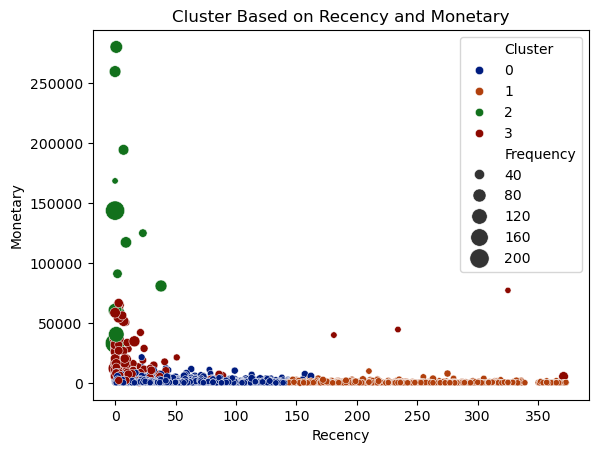

In [18]:
# Scatter plot: Recency vs Monetary, size=Frequency, color=Cluster
sns.scatterplot(x='Recency', y='Monetary', size='Frequency', hue='Cluster', palette='dark', data=rfm, sizes=(20,200))
plt.title("Cluster Based on Recency and Monetary")
plt.show()

## Key Insights from Cluster Analysis

- Identify Best Customers (Champions): These customers bring the most revenue. Focus on rewarding them to retain loyalty.
- Spot At-Risk Customers: Customers who may churn. Target them with campaigns or offers to re-engage.
- Target Potential Customers: Loyal or new customers who can be encouraged to increase purchases.

In [20]:
# Save RFM table to CSV
rfm.to_csv("~/Customer-Segmentation-and-Churn-Analysis/data/rfm.csv",index = False)

## Conclusion

- Customer segmentation was successfully performed using clustering techniques.
- Distinct customer groups were identified based on purchasing behavior.
- These insights can be used to design targeted marketing and retention strategies.
- Clustering enables businesses to allocate resources effectively and improve customer retention and revenue.